# Notebook 3 — Embedding + HNSW Indexing + Ablation Study + Evaluation
## Visual Product Search Engine | DeepFashion In-Shop Clothes Retrieval

**Pipeline:**
1. Query/Gallery split
2. Embedding generation (fusion formula: `v_i = α·φ_V(crop) + (1-α)·φ_T(caption)`)
3. HNSW index build
4. Ablation study (Config A / B / C)
5. Retrieval metrics: Recall@K, NDCG@K, mAP@K for K ∈ {5, 10, 15}
6. Multi-seed evaluation (mean ± std)
7. Save outputs for Streamlit demo

## 0. Install Dependencies

In [42]:
!pip install -q hnswlib transformers accelerate

## 1. Imports & Paths

In [43]:
import os, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import torch
import hnswlib
from transformers import CLIPModel, CLIPProcessor

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
WORK_DIR = Path('/kaggle/working')
OUT_DIR  = WORK_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

METADATA_CSV = Path('/kaggle/input/datasets/saisathviksvn/metadata/metadata_parthiv.csv')

DEEPFASHION_DIR     = Path('/kaggle/input/datasets/svnsaisathvik/text-images')
IMG_DIR             = DEEPFASHION_DIR / 'img' / 'img'
EVAL_PARTITION_FILE = DEEPFASHION_DIR / 'list_eval_partition.txt'

CKPT_DIR       = Path('/kaggle/input/models/saisathviksvn/model-with-seeds/pytorch/default/1')
BEST_CLIP_CKPT = CKPT_DIR / 'best_clip.pt'
SEED_CKPTS     = {
    1:   CKPT_DIR / 'best_clip_seed1.pt',
    52:  CKPT_DIR / 'best_clip_seed52.pt',
    525: CKPT_DIR / 'best_clip_seed525.pt',
}

CLIP_BASE_MODEL = 'openai/clip-vit-base-patch32'
K_VALUES        = [5, 10, 15]
BATCH_SIZE      = 64
DIM             = 512
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device : {DEVICE}')
print(f'IMG_DIR exists : {IMG_DIR.exists()}')
print(f'Eval partition : {EVAL_PARTITION_FILE.exists()}')
print(f'best_clip.pt   : {BEST_CLIP_CKPT.exists()}')

Device : cuda
IMG_DIR exists : True
Eval partition : True
best_clip.pt   : True


## 2. Load Metadata

In [44]:
meta = pd.read_csv(METADATA_CSV)
print(f'Total rows : {len(meta):,}')
print(f'Columns    : {meta.columns.tolist()}')
meta.head(3)

Total rows : 52,712
Columns    : ['image_path', 'item_id', 'gender', 'category', 'crop_path', 'caption', 'bbox', 'confidence', 'detection_status']


,image_path,item_id,gender,category,crop_path,caption,bbox,confidence,detection_status
0,/kaggle/input/datasets/abhinavkishan123/deepfa...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,The black skinny jeans,"[66,0,207,256]",0.8184,success
1,/kaggle/input/datasets/abhinavkishan123/deepfa...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,black skinny jeans,"[99,0,175,256]",0.7378,success
2,/kaggle/input/datasets/abhinavkishan123/deepfa...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,Jeans,"[62,0,190,256]",0.7669,success


## 2b. Fix Image Paths  *(key fix — resolves blank-image issue)*

In [47]:
# ── Fast vectorized path resolution ──────────────────────────────────────
import os

_MARKER = '/img/img/'

# Step 1: Construct all remapped paths at once (pure string ops, no disk I/O)
def extract_rel(image_path):
    idx = image_path.find(_MARKER)
    return image_path[idx + len(_MARKER):] if idx != -1 else ''

meta['_rel']           = meta['image_path'].apply(extract_rel)
meta['_remapped_path'] = meta['_rel'].apply(
    lambda r: str(IMG_DIR / r) if r else ''
)

# Step 2: Batch existence check using os.path.exists (faster than Path.exists)
print('Checking remapped paths …')
remapped_exists = [os.path.exists(p) for p in meta['_remapped_path']]
crop_exists     = [os.path.exists(p) for p in meta['crop_path']]

# Step 3: Pick best available path
def pick_path(crop, crop_ok, remapped, remap_ok, orig):
    if crop_ok:     return crop
    if remap_ok:    return remapped
    return orig

meta['resolved_path'] = [
    pick_path(c, c_ok, r, r_ok, o)
    for c, c_ok, r, r_ok, o
    in zip(meta['crop_path'], crop_exists,
           meta['_remapped_path'], remapped_exists,
           meta['image_path'])
]

# Cleanup temp cols
meta.drop(columns=['_rel', '_remapped_path'], inplace=True)

n_ok = sum(remapped_exists) + sum(c and not r for c, r in zip(crop_exists, remapped_exists))
print(f'  Resolved OK  : {n_ok:,} / {len(meta):,}')
print(f'  Still missing: {len(meta)-n_ok:,}  ({100*(len(meta)-n_ok)/len(meta):.1f}%)')
print(f'  Sample: {meta["resolved_path"].iloc[0]}')

Checking remapped paths …
  Resolved OK  : 52,712 / 52,712
  Still missing: 0  (0.0%)
  Sample: /kaggle/input/datasets/svnsaisathvik/text-images/img/img/MEN/Denim/id_00000080/01_1_front.jpg


## 3. Query / Gallery Split

In [57]:
def load_split_from_partition(partition_file: Path, meta: pd.DataFrame):
    """Parse list_eval_partition.txt and join on image basename key."""
    print('Using list_eval_partition.txt for split …')
    partition = {}
    with open(partition_file) as f:
        next(f)   # count line
        next(f)   # header line
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                partition[parts[0]] = parts[2]   # img/... → train/query/gallery

    def to_key(image_path: str) -> str:
        marker = '/img/img/'
        idx = image_path.find(marker)
        if idx != -1:
            return 'img/' + image_path[idx + len(marker):]
        return image_path

    meta = meta.copy()
    meta['_key']  = meta['image_path'].apply(to_key)
    meta['split'] = meta['_key'].map(partition)

    # Just print the summary counts, not every item
    counts = meta['split'].value_counts(dropna=False)
    print(f'  train  : {counts.get("train",  0):,}')
    print(f'  gallery: {counts.get("gallery", 0):,}')
    print(f'  query  : {counts.get("query",   0):,}')
    print(f'  unmatched: {meta["split"].isna().sum():,}')

    gallery_df = meta[meta['split'] == 'gallery'].reset_index(drop=True)
    query_df   = meta[meta['split'] == 'query'].reset_index(drop=True)
    return query_df, gallery_df


def make_fallback_split(meta: pd.DataFrame, query_frac: float = 0.2, seed: int = 42):
    """20% query / 80% gallery split per item_id."""
    print('list_eval_partition.txt not found — using 20/80 fallback split …')
    rng = np.random.default_rng(seed)
    query_idx, gallery_idx = [], []
    for _, group in meta.groupby('item_id'):
        idx = group.index.tolist()
        rng.shuffle(idx)
        n_q = max(1, int(len(idx) * query_frac))
        query_idx.extend(idx[:n_q])
        gallery_idx.extend(idx[n_q:])
    return meta.loc[query_idx].reset_index(drop=True), meta.loc[gallery_idx].reset_index(drop=True)


if EVAL_PARTITION_FILE.exists():
    query_df, gallery_df = load_split_from_partition(EVAL_PARTITION_FILE, meta)
else:
    query_df, gallery_df = make_fallback_split(meta)

print(f'\nQuery   : {len(query_df):,} images')
print(f'Gallery : {len(gallery_df):,} images')

gallery_df[['item_id', 'resolved_path', 'caption', 'gender', 'category']].rename(
    columns={'resolved_path': 'crop_path'}
).to_csv(OUT_DIR / 'gallery_metadata.csv', index=False)
print('Saved gallery_metadata.csv')

Using list_eval_partition.txt for split …
  train  : 25,882
  gallery: 12,612
  query  : 14,218
  unmatched: 0

Query   : 14,218 images
Gallery : 12,612 images
Saved gallery_metadata.csv


## 4. CLIP Loading Utilities

In [58]:
def load_clip(checkpoint_path=None):
    """Load CLIP.  checkpoint_path=None → frozen pretrained."""
    model     = CLIPModel.from_pretrained(CLIP_BASE_MODEL)
    processor = CLIPProcessor.from_pretrained(CLIP_BASE_MODEL)

    if checkpoint_path is not None:
        print(f'  Loading fine-tuned weights: {Path(checkpoint_path).name} …')
        state = torch.load(checkpoint_path, map_location='cpu')
        if isinstance(state, dict) and 'model_state_dict' in state:
            state = state['model_state_dict']
        missing, unexpected = model.load_state_dict(state, strict=False)
        print(f'  Missing={len(missing)}  Unexpected={len(unexpected)}')

    model.eval().to(DEVICE)
    return model, processor


def _image_features(model, pixel_values):
    """Extract CLIP image features — works across all transformers versions."""
    out = model.vision_model(pixel_values=pixel_values)
    return model.visual_projection(out.pooler_output)   # (B, 512)


def _text_features(model, input_ids, attention_mask):
    """Extract CLIP text features — works across all transformers versions."""
    out = model.text_model(input_ids=input_ids, attention_mask=attention_mask)
    return model.text_projection(out.pooler_output)     # (B, 512)

## 5. Embedding Generation

In [59]:
@torch.no_grad()
def generate_embeddings(df: pd.DataFrame,
                        model, processor,
                        alpha: float,
                        batch_size: int = BATCH_SIZE,
                        desc: str = '') -> np.ndarray:
    """
    v_i = alpha * phi_V(image_i) + (1-alpha) * phi_T(caption_i),  ||v_i||=1
    Uses 'resolved_path' column if present, else 'crop_path'.
    """
    path_col = 'resolved_path' if 'resolved_path' in df.columns else 'crop_path'
    all_embeds = []

    for start in tqdm(range(0, len(df), batch_size), desc=desc or 'Embedding'):
        batch = df.iloc[start : start + batch_size]

        # ── Load images ───────────────────────────────────────────────────
        images = []
        for path in batch[path_col]:
            try:
                images.append(Image.open(str(path)).convert('RGB'))
            except Exception:
                images.append(Image.new('RGB', (224, 224), color=(128, 128, 128)))

        # ── Vision embeddings ─────────────────────────────────────────────
        img_in  = processor(images=images, return_tensors='pt', padding=True)
        px_vals = img_in['pixel_values'].to(DEVICE)
        img_f   = _image_features(model, px_vals)
        img_f   = img_f / img_f.norm(dim=-1, keepdim=True)

        # ── Text embeddings ───────────────────────────────────────────────
        captions  = batch['caption'].fillna('').tolist()
        txt_in    = processor(text=captions, return_tensors='pt',
                              padding=True, truncation=True, max_length=77)
        input_ids = txt_in['input_ids'].to(DEVICE)
        attn_mask = txt_in['attention_mask'].to(DEVICE)
        txt_f     = _text_features(model, input_ids, attn_mask)
        txt_f     = txt_f / txt_f.norm(dim=-1, keepdim=True)

        # ── Fusion ────────────────────────────────────────────────────────
        fused = alpha * img_f + (1.0 - alpha) * txt_f
        fused = fused / fused.norm(dim=-1, keepdim=True)

        all_embeds.append(fused.cpu().float().numpy())

    return np.vstack(all_embeds).astype(np.float32)

## 6. HNSW Index Utilities

In [60]:
def build_hnsw_index(embeddings: np.ndarray,
                     ef_construction: int = 200,
                     M: int = 32) -> hnswlib.Index:
    idx = hnswlib.Index(space='cosine', dim=embeddings.shape[1])
    idx.init_index(max_elements=len(embeddings),
                   ef_construction=ef_construction, M=M)
    idx.add_items(embeddings, list(range(len(embeddings))))
    idx.set_ef(max(50, ef_construction))
    return idx


def hnsw_search(index, query_embeds, k):
    labels, distances = index.knn_query(query_embeds, k=k)
    return labels, distances

## 7. Retrieval Metrics

In [61]:
def compute_metrics(query_df, gallery_df, labels, k):
    gallery_ids = gallery_df['item_id'].values
    query_ids   = query_df['item_id'].values
    recall_list, ndcg_list, ap_list = [], [], []

    for qi in range(len(query_df)):
        q_item    = query_ids[qi]
        top_k     = labels[qi][:k]
        relevance = (gallery_ids[top_k] == q_item).astype(float)

        # Recall@K
        recall_list.append(1.0 if relevance.sum() > 0 else 0.0)

        # NDCG@K
        dcg        = float(np.sum(relevance / np.log2(np.arange(2, k + 2))))
        n_rel      = int((gallery_ids == q_item).sum())
        ideal_hits = min(k, n_rel)
        idcg       = float(np.sum(1.0 / np.log2(np.arange(2, ideal_hits + 2)))) if ideal_hits else 0.0
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

        # mAP@K
        hits, ap = 0, 0.0
        for rank, rel in enumerate(relevance, 1):
            if rel:
                hits += 1
                ap   += hits / rank
        denom = min(k, n_rel) if n_rel > 0 else 1
        ap_list.append(ap / denom)

    return {
        f'Recall@{k}': float(np.mean(recall_list)),
        f'NDCG@{k}'  : float(np.mean(ndcg_list)),
        f'mAP@{k}'   : float(np.mean(ap_list)),
    }


def evaluate_config(query_df, gallery_df, gallery_embeds, query_embeds, label):
    print(f'  Building HNSW index …')
    index = build_hnsw_index(gallery_embeds)
    max_k = max(K_VALUES)
    labels_mat, _ = hnsw_search(index, query_embeds, k=max_k)
    results = {'config': label}
    for k in K_VALUES:
        results.update(compute_metrics(query_df, gallery_df, labels_mat, k))
    for key, val in results.items():
        if key != 'config':
            print(f'    {key}: {val:.4f}')
    return results, index, labels_mat

## 8. Ablation — Config A (Frozen CLIP, α=1.0, vision-only baseline)

In [62]:
all_results = []

print('\n=== CONFIG A: Frozen pretrained CLIP, alpha=1.0 ===')
model_A, proc_A = load_clip(checkpoint_path=None)

gallery_embeds_A = generate_embeddings(gallery_df, model_A, proc_A, alpha=1.0, desc='Config A gallery')
query_embeds_A   = generate_embeddings(query_df,   model_A, proc_A, alpha=1.0, desc='Config A query')

res_A, _, _ = evaluate_config(query_df, gallery_df, gallery_embeds_A, query_embeds_A,
                               label='A: Frozen CLIP α=1.0')
all_results.append(res_A)

del model_A, proc_A, gallery_embeds_A, query_embeds_A
gc.collect(); torch.cuda.empty_cache()


=== CONFIG A: Frozen pretrained CLIP, alpha=1.0 ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Config A gallery:   0%|          | 0/198 [00:00<?, ?it/s]

Config A query:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.6721
    NDCG@5: 0.3557
    mAP@5: 0.2748
    Recall@10: 0.7423
    NDCG@10: 0.3617
    mAP@10: 0.2651
    Recall@15: 0.7804
    NDCG@15: 0.3719
    mAP@15: 0.2666


## 9. Ablation — Config B (Frozen CLIP + captions)

In [63]:
model_B, proc_B = load_clip(checkpoint_path=None)

for alpha in [0.7, 0.5]:
    print(f'\n=== CONFIG B: Frozen pretrained CLIP, alpha={alpha} ===')
    gal_B = generate_embeddings(gallery_df, model_B, proc_B, alpha=alpha, desc=f'Config B gallery α={alpha}')
    qry_B = generate_embeddings(query_df,   model_B, proc_B, alpha=alpha, desc=f'Config B query α={alpha}')
    res_B, _, _ = evaluate_config(query_df, gallery_df, gal_B, qry_B,
                                   label=f'B: Frozen CLIP α={alpha}')
    all_results.append(res_B)

del model_B, proc_B, gal_B, qry_B
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== CONFIG B: Frozen pretrained CLIP, alpha=0.7 ===


Config B gallery α=0.7:   0%|          | 0/198 [00:00<?, ?it/s]

Config B query α=0.7:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.6891
    NDCG@5: 0.3751
    mAP@5: 0.2951
    Recall@10: 0.7607
    NDCG@10: 0.3846
    mAP@10: 0.2890
    Recall@15: 0.7974
    NDCG@15: 0.3955
    mAP@15: 0.2911

=== CONFIG B: Frozen pretrained CLIP, alpha=0.5 ===


Config B gallery α=0.5:   0%|          | 0/198 [00:00<?, ?it/s]

Config B query α=0.5:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.5506
    NDCG@5: 0.2839
    mAP@5: 0.2193
    Recall@10: 0.6256
    NDCG@10: 0.2931
    mAP@10: 0.2151
    Recall@15: 0.6726
    NDCG@15: 0.3035
    mAP@15: 0.2171


## 10. Ablation — Config C (Fine-tuned CLIP + captions)

In [64]:
model_C, proc_C = load_clip(checkpoint_path=BEST_CLIP_CKPT)
best_index = best_labels = best_gallery_embs = best_query_embs = None

for alpha in [0.7, 0.5]:
    print(f'\n=== CONFIG C: Fine-tuned CLIP (best_clip.pt), alpha={alpha} ===')
    gal_C = generate_embeddings(gallery_df, model_C, proc_C, alpha=alpha, desc=f'Config C gallery α={alpha}')
    qry_C = generate_embeddings(query_df,   model_C, proc_C, alpha=alpha, desc=f'Config C query α={alpha}')
    res_C, idx_C, lbl_C = evaluate_config(query_df, gallery_df, gal_C, qry_C,
                                           label=f'C: Fine-tuned CLIP α={alpha}')
    all_results.append(res_C)

    if alpha == 0.7:
        best_index       = idx_C
        best_labels      = lbl_C
        best_gallery_embs = gal_C
        best_query_embs   = qry_C

del model_C, proc_C
gc.collect(); torch.cuda.empty_cache()
print('\n✅ Config C done.')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading fine-tuned weights: best_clip.pt …
  Missing=0  Unexpected=0

=== CONFIG C: Fine-tuned CLIP (best_clip.pt), alpha=0.7 ===


Config C gallery α=0.7:   0%|          | 0/198 [00:00<?, ?it/s]

Config C query α=0.7:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.6910
    NDCG@5: 0.3729
    mAP@5: 0.2923
    Recall@10: 0.7685
    NDCG@10: 0.3824
    mAP@10: 0.2863
    Recall@15: 0.8033
    NDCG@15: 0.3927
    mAP@15: 0.2883

=== CONFIG C: Fine-tuned CLIP (best_clip.pt), alpha=0.5 ===


Config C gallery α=0.5:   0%|          | 0/198 [00:00<?, ?it/s]

Config C query α=0.5:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.5720
    NDCG@5: 0.2947
    mAP@5: 0.2270
    Recall@10: 0.6537
    NDCG@10: 0.3049
    mAP@10: 0.2232
    Recall@15: 0.6993
    NDCG@15: 0.3151
    mAP@15: 0.2251

✅ Config C done.


## 11. Multi-Seed Evaluation — Config C, α=0.7

In [65]:
seed_results = []

for seed, ckpt in SEED_CKPTS.items():
    if not ckpt.exists():
        print(f'⚠  Skipping seed {seed} — checkpoint not found: {ckpt}')
        continue
    print(f'\n=== Multi-seed eval — seed {seed} (α=0.7) ===')
    model_s, proc_s = load_clip(checkpoint_path=ckpt)
    gal_s = generate_embeddings(gallery_df, model_s, proc_s, alpha=0.7, desc=f'Seed {seed} gallery')
    qry_s = generate_embeddings(query_df,   model_s, proc_s, alpha=0.7, desc=f'Seed {seed} query')
    res_s, _, _ = evaluate_config(query_df, gallery_df, gal_s, qry_s,
                                   label=f'C_seed{seed} α=0.7')
    seed_results.append(res_s)
    all_results.append(res_s)
    del model_s, proc_s, gal_s, qry_s
    gc.collect(); torch.cuda.empty_cache()

# Mean ± std
if seed_results:
    seed_df  = pd.DataFrame(seed_results)
    m_cols   = [c for c in seed_df.columns if c != 'config']
    means    = seed_df[m_cols].mean()
    stds     = seed_df[m_cols].std()
    print('\n=== Multi-seed summary (mean ± std) ===')
    for col in m_cols:
        print(f'  {col}: {means[col]:.4f} ± {stds[col]:.4f}')
    mean_row = means.to_dict(); mean_row['config'] = 'C_multiseed_mean'
    std_row  = stds.to_dict();  std_row['config']  = 'C_multiseed_std'
    all_results.extend([mean_row, std_row])


=== Multi-seed eval — seed 1 (α=0.7) ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading fine-tuned weights: best_clip_seed1.pt …
  Missing=0  Unexpected=0


Seed 1 gallery:   0%|          | 0/198 [00:00<?, ?it/s]

...

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading fine-tuned weights: best_clip_seed525.pt …
  Missing=0  Unexpected=0


Seed 525 gallery:   0%|          | 0/198 [00:00<?, ?it/s]

Seed 525 query:   0%|          | 0/223 [00:00<?, ?it/s]

  Building HNSW index …
    Recall@5: 0.6911
    NDCG@5: 0.3729
    mAP@5: 0.2923
    Recall@10: 0.7685
    NDCG@10: 0.3825
    mAP@10: 0.2863
    Recall@15: 0.8033
    NDCG@15: 0.3927
    mAP@15: 0.2883

=== Multi-seed summary (mean ± std) ===
  Recall@5: 0.6802 ± 0.0098
  NDCG@5: 0.3642 ± 0.0082
  mAP@5: 0.2847 ± 0.0073
  Recall@10: 0.7573 ± 0.0106
  NDCG@10: 0.3737 ± 0.0082
  mAP@10: 0.2792 ± 0.0068
  Recall@15: 0.7956 ± 0.0075
  NDCG@15: 0.3843 ± 0.0079
  mAP@15: 0.2814 ± 0.0067


## 12. Save ablation_results.csv

In [66]:
ablation_df = pd.DataFrame(all_results)
cols_order  = ['config'] + [f'{m}@{k}' for k in K_VALUES for m in ['Recall', 'NDCG', 'mAP']]
cols_order  = [c for c in cols_order if c in ablation_df.columns]
ablation_df = ablation_df[cols_order]
ablation_df.to_csv(OUT_DIR / 'ablation_results.csv', index=False)
print('Saved ablation_results.csv')
ablation_df

Saved ablation_results.csv


,config,Recall@5,NDCG@5,mAP@5,Recall@10,NDCG@10,mAP@10,Recall@15,NDCG@15,mAP@15
0,A: Frozen CLIP α=1.0,0.672106,0.355725,0.274842,0.742298,0.361667,0.265094,0.780419,0.371898,0.266552
1,B: Frozen CLIP α=0.7,0.689126,0.375131,0.295111,0.760726,0.384631,0.288996,0.797440,0.395451,0.291057
2,B: Frozen CLIP α=0.5,0.550640,0.283867,0.219293,0.625615,0.293100,0.215146,0.672598,0.303451,0.217095
3,C: Fine-tuned CLIP α=0.7,0.691025,0.372868,0.292270,0.768463,0.382424,0.286317,0.803278,0.392681,0.288281
4,C: Fine-tuned CLIP α=0.5,0.572021,0.294656,0.226967,0.653678,0.304852,0.223166,0.699254,0.315148,0.225119
5,C_seed1 α=0.7,0.677521,0.362987,0.283954,0.755732,0.372378,0.278529,0.795119,0.383224,0.280773
6,C_seed52 α=0.7,0.672106,0.356586,0.277749,0.747503,0.366252,0.272795,0.788297,0.377016,0.275000
7,C_seed525 α=0.7,0.691096,0.372896,0.292287,0.768533,0.382453,0.286336,0.803348,0.392702,0.288294
8,C_multiseed_mean,0.680241,0.364157,0.284663,0.757256,0.373694,0.279220,0.795588,0.384314,0.281356
9,C_multiseed_std,0.009783,0.008217,0.007295,0.010597,0.008180,0.006797,0.007537,0.007900,0.006666


## 13. Save HNSW Index

In [67]:
best_index.save_index(str(OUT_DIR / 'hnsw_index_best.bin'))
print(f'Saved hnsw_index_best.bin')

Saved hnsw_index_best.bin


## 14. Visualisations — Bar Charts

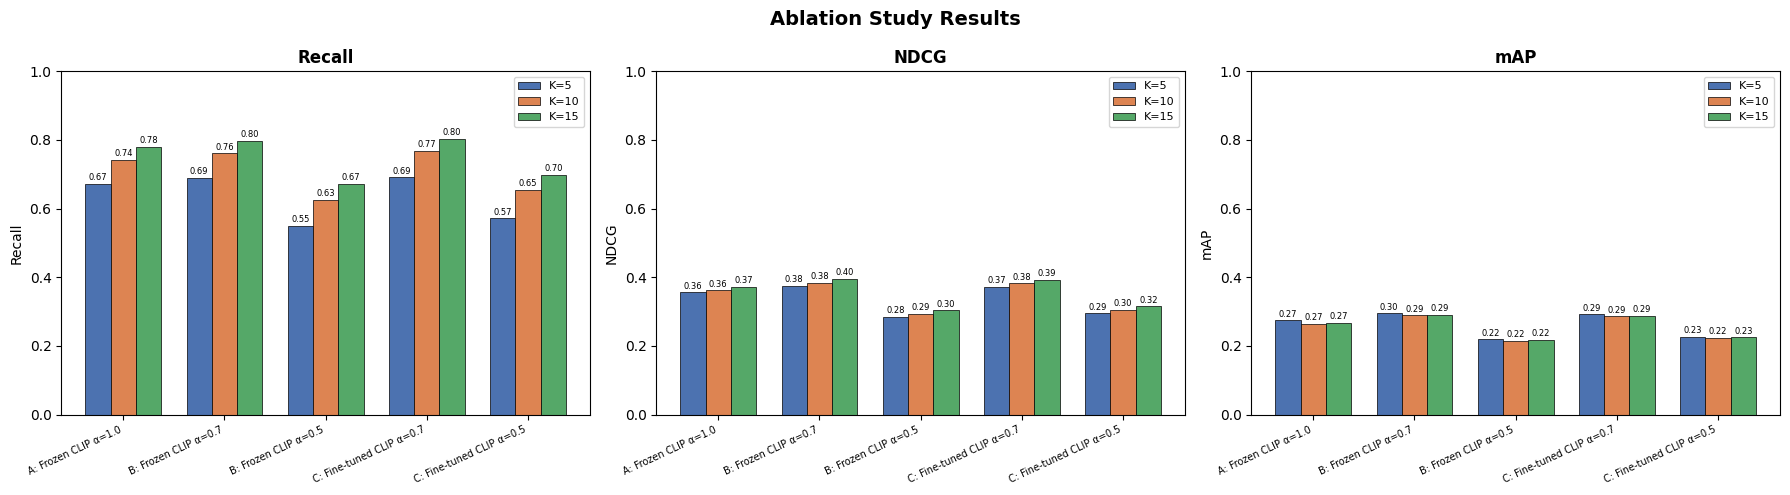

Saved ablation_bar_charts.png


In [68]:
plot_df = ablation_df[~ablation_df['config'].str.contains('seed|mean|std', na=False)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4c72b0','#dd8452','#55a868','#c44e52','#8172b2']

for ax, metric in zip(axes, ['Recall', 'NDCG', 'mAP']):
    x     = np.arange(len(plot_df))
    width = 0.25
    for i, k in enumerate(K_VALUES):
        col = f'{metric}@{k}'
        if col in plot_df.columns:
            bars = ax.bar(x + i * width, plot_df[col], width,
                          label=f'K={k}', color=colors[i], edgecolor='black', linewidth=0.5)
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(x + width)
    ax.set_xticklabels(plot_df['config'], rotation=25, ha='right', fontsize=7)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.0)

plt.suptitle('Ablation Study Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'ablation_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_bar_charts.png')

## 15. Top-5 Retrieval Examples

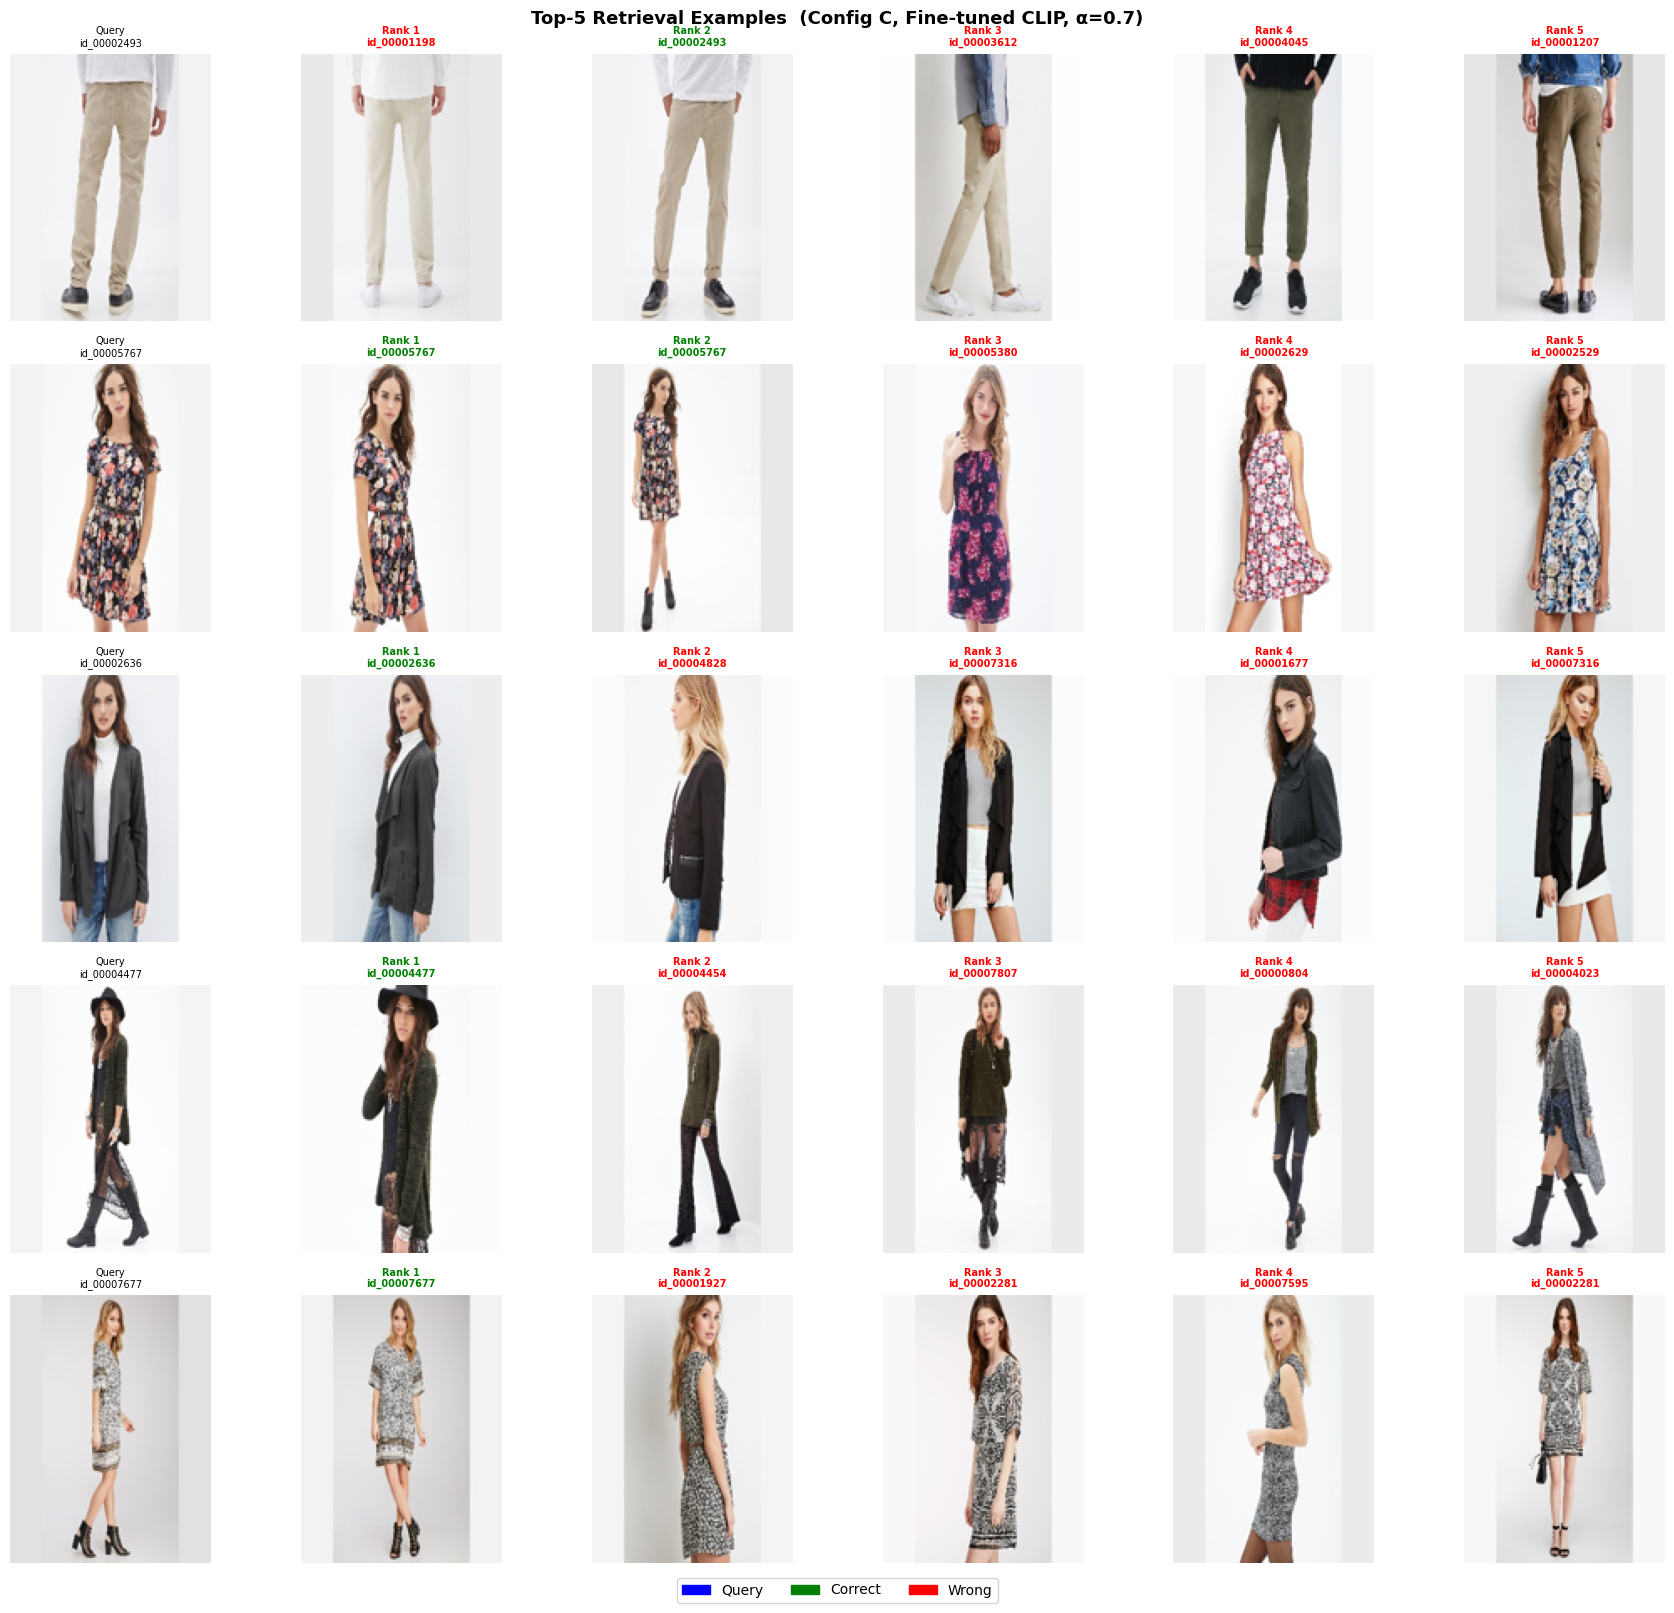

Saved retrieval_examples.png


In [69]:
gallery_item_ids = gallery_df['item_id'].values
query_item_ids   = query_df['item_id'].values

_PATH_COL = 'resolved_path' if 'resolved_path' in gallery_df.columns else 'crop_path'
_MARKER   = '/img/img/'

def load_thumb(row, size=(120, 160)):
    """Try resolved_path → remap image_path → grey box."""
    # 1. Use resolved_path / crop_path
    try:
        p = str(row.get(_PATH_COL, row.get('crop_path', '')))
        if Path(p).exists():
            return Image.open(p).convert('RGB').resize(size)
    except Exception:
        pass
    # 2. Remap image_path
    try:
        orig = str(row.get('image_path', ''))
        idx  = orig.find(_MARKER)
        if idx != -1:
            rel = orig[idx + len(_MARKER):]
            p2  = IMG_DIR / rel
            if p2.exists():
                return Image.open(str(p2)).convert('RGB').resize(size)
    except Exception:
        pass
    # 3. Grey placeholder
    return Image.new('RGB', size, color=(180, 180, 180))

N_EXAMPLES = 5
TOP_SHOW   = 5

# Prefer queries that have ≥1 correct hit in top-5
rng      = np.random.default_rng(42)
cand_idx = rng.choice(len(query_df), size=min(300, len(query_df)), replace=False)
chosen   = []
for qi in cand_idx:
    if any(gallery_item_ids[best_labels[qi][:5]] == query_item_ids[qi]):
        chosen.append(qi)
    if len(chosen) == N_EXAMPLES:
        break
if len(chosen) < N_EXAMPLES:
    chosen = list(cand_idx[:N_EXAMPLES])

fig, axes = plt.subplots(N_EXAMPLES, TOP_SHOW + 1,
                          figsize=(3*(TOP_SHOW+1), 3.2*N_EXAMPLES))

for row_i, qi in enumerate(chosen):
    q_item = query_item_ids[qi]

    ax = axes[row_i, 0]
    ax.imshow(load_thumb(query_df.iloc[qi]))
    ax.set_title(f'Query\n{q_item}', fontsize=7)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor('blue'); sp.set_linewidth(4)

    for col_i, gal_idx in enumerate(best_labels[qi][:TOP_SHOW], start=1):
        g_item  = gallery_item_ids[gal_idx]
        correct = (g_item == q_item)
        color   = 'green' if correct else 'red'
        ax = axes[row_i, col_i]
        ax.imshow(load_thumb(gallery_df.iloc[gal_idx]))
        ax.set_title(f'Rank {col_i}\n{g_item}', fontsize=7,
                     color=color, fontweight='bold')
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor(color); sp.set_linewidth(4)

fig.legend(handles=[
    mpatches.Patch(color='blue',  label='Query'),
    mpatches.Patch(color='green', label='Correct'),
    mpatches.Patch(color='red',   label='Wrong'),
], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Top-5 Retrieval Examples  (Config C, Fine-tuned CLIP, α=0.7)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'retrieval_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved retrieval_examples.png')

## 16. Final Output Summary

In [70]:
print('=== All outputs saved to /kaggle/working/ ===')
for f in sorted(OUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size/1e6:>8.2f} MB')

=== All outputs saved to /kaggle/working/ ===
  ablation_bar_charts.png                           0.08 MB
  ablation_map.png                                  0.06 MB
  ablation_ndcg.png                                 0.06 MB
  ablation_recall.png                               0.06 MB
  ablation_results.csv                              0.00 MB
  gallery_metadata.csv                              1.91 MB
  hnsw_index_best.bin                              29.31 MB
  multiseed_results.png                             0.06 MB
  retrieval_examples.png                            2.10 MB
